## In-situ

In this notebook, we use the copula-generated samples to derive the X-year bivariate return period isolines for storm surge (NTR) and rainfall (RF). The trivariate copula samples (NTR, RF, RD) were previously generated, and here we use them to identify the NTR–RF combinations corresponding to specific return periods. The associated river discharge (RD) values from the same samples are then assigned to these isolines to represent compound flood conditions.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from scipy.ndimage import gaussian_filter
from scipy.stats import gaussian_kde
from scipy.spatial import Delaunay
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from scipy.ndimage import gaussian_filter
from scipy.stats import gaussian_kde
from scipy.spatial import cKDTree
from matplotlib.lines import Line2D
import matplotlib.cm as cm


In [ ]:

locations = ['OceanSprings']
prop = ['TimeVarying', 'Stationary']
dataset =['','Reanalysis']

acc_hr = 'acc_24hr'

sim_ntr_col = 'Sim_NTR'
sim_rf_col = 'Sim_RF'
sim_rd_col = 'Sim_RD'
density_col = 'density'

core_directory = Path(r'C:/Users/sadaf/Desktop/Generating_Boundary_Conditions/POT_24hr_Jan26/Trivariate')

In [ ]:
file_names = [
    "Simulated_Backtransformed_RD_NTR_RF.csv",
    "Simulated_Backtransformed_RF_NTR_RD.csv",
    "Simulated_Backtransformed_NTR_RF_RD.csv"
]

for file_name in file_names:
    for location in locations:
        for p in prop:
            for d in dataset:
                input_file = core_directory / location / d / p / file_name
                df = pd.read_csv(input_file)
                if file_name == 'Simulated_Backtransformed_RD_NTR_RF.csv':
                    df['density'] = df['C12']
                else:
                    df['density'] = df['C13']
                df.to_csv(input_file, index=False)

In [3]:
for loc in locations:
    for p in prop:
        for data in dataset:
            
            if data == 'Reanalysis':
                target_events = '10'
            else:
                target_events = '5'

            # File paths
            
            file_names = [
                "Simulated_Backtransformed_RD_NTR_RF.csv",
                "Simulated_Backtransformed_RF_NTR_RD.csv",
                "Simulated_Backtransformed_NTR_RF_RD.csv"
            ]
            
            # Read and concatenate
            dfs = [pd.read_csv(f"{core_directory}\{loc}\{data}\{p}\{fname}") for fname in file_names]
            df_all = pd.concat(dfs, ignore_index=True)
            df_all.to_csv(rf'{core_directory}\{loc}\{data}\{p}\Simulated_Backtransformed_ALL_Combined_{target_events}_with_Density.csv', index=False)
            


In [ ]:

def assign_rd_random_band(samples_xy, rp_target, df, rp_field,
                        k_neighbors=30, rel_band=0.20, rng=None):
    """
    Random RD draw for each (NTR, RF) vertex from points in df whose
    bivariate return period is near rp_target (± rel_band).
    Falls back by widening the band, then to full df if needed.
    """
    if rng is None:
        rng = np.random.default_rng()

    # 1) band around the target RP
    rp_low, rp_high = rp_target * (1 - rel_band), rp_target * (1 + rel_band)
    mask = (df[rp_field] >= rp_low) & (df[rp_field] <= rp_high)

    # If too few, relax once
    if mask.sum() < 50:
        rel_band2 = max(rel_band, 0.35)
        rp_low, rp_high = rp_target * (1 - rel_band2), rp_target * (1 + rel_band2)
        mask = (df[rp_field] >= rp_low) & (df[rp_field] <= rp_high)

    # If still too few, fall back to full df (last resort)
    if mask.sum() == 0:
        mask = np.ones(len(df), dtype=bool)

    X_band = df.loc[mask, ['Sim_NTR', 'Sim_RF']].to_numpy()
    RD_band = df.loc[mask, 'Sim_RD'].to_numpy()

    # 2) KD-tree within the band
    if len(X_band) < 2:
        # degenerate fallback: random choice from RD_band
        return rng.choice(RD_band, size=samples_xy.shape[0], replace=True)

    from scipy.spatial import cKDTree
    tree_b = cKDTree(X_band)
    k = min(k_neighbors, len(X_band))
    eps = 1e-9

    # 3) For each vertex: draw ONE neighbor by distance-weighted sampling
    dists, idxs = tree_b.query(samples_xy, k=k)
    if np.ndim(dists) == 1:
        dists = dists[:, None]
        idxs  = idxs[:, None]

    out = np.empty(samples_xy.shape[0])
    for i in range(samples_xy.shape[0]):
        di = dists[i] + eps
        wi = 1.0 / di
        wi /= wi.sum()
        pick = rng.choice(idxs[i], p=wi)  # pick ONE neighbor at random
        out[i] = RD_band[pick]
    return out

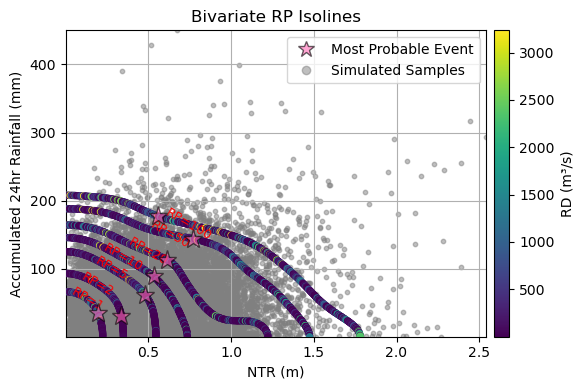

In [ ]:

for data in dataset:
    for loc in locations:
        for p in prop:
            # File paths
            base_path = core_directory / Path(f'{loc}/{data}/{p}')

            if data == '':
                target_events = 5
            else:
                target_events = 10

            df = pd.read_csv(rf'{base_path}/Simulated_Backtransformed_ALL_Combined_{target_events}_with_Density.csv')
        
            rp_field = 'ReturnPeriod_bivariate' if 'ReturnPeriod_bivariate' in df.columns else 'ReturnPeriod_Bivariate'
            df = df[df[rp_field] > 0]

            # --------- Return periods to draw --------
            rp_vals = [1, 2, 5, 10, 20, 50, 100]

            # --------- Grid (use data extent) ---------
            x_min, x_max = df[sim_ntr_col].min(), df[sim_ntr_col].max()
            y_min, y_max = df[sim_rf_col].min(),  df[sim_rf_col].max()
            x = np.linspace(x_min, x_max, 500)
            y = np.linspace(y_min, y_max, 500)
            X, Y = np.meshgrid(x, y)

            # --------- Interpolate RP surface (second approach) ---------
            points = df[[sim_ntr_col, sim_rf_col]].values
            rp_vals_all = df[rp_field].values

            Z_linear  = griddata(points, rp_vals_all, (X, Y), method='linear')

            x_min_, x_max_ = x.min(), x.max()
            y_min_, y_max_ = y.min(), y.max()

            def norm_xy(xv, yv):
                return np.column_stack([(xv - x_min_) / (x_max_ - x_min_ + 1e-12),
                                        (yv - y_min_) / (y_max_ - y_min_ + 1e-12)])

            pts_n = norm_xy(points[:,0], points[:,1])
            tree  = cKDTree(pts_n)

            grid_n = norm_xy(X.ravel(), Y.ravel())

            # 3) nearest neighbor & k-NN for IDW
            k = 6
            d_near, i_near = tree.query(grid_n, k=1)
            d_knn , i_knn  = tree.query(grid_n, k=min(k, len(points)))

            if d_knn.ndim == 1:  # handle case k=1
                d_knn = d_knn[:, None]
                i_knn = i_knn[:, None]

            vals_knn = rp_vals_all[i_knn]                    # (Npix, k)
            w = 1.0 / (d_knn**2 + 1e-12)                     # IDW weights, p=2
            w /= w.sum(axis=1, keepdims=True)
            Z_idw = (w * vals_knn).sum(axis=1).reshape(X.shape)

            # 4) classic nearest (but we won't use it blindly)
            Z_nearest = griddata(points, rp_vals_all, (X, Y), method='nearest')

            # 5) only fill NaNs that are **close** to data, blend nearest↔IDW by distance
            #    threshold & blending width in *normalized* units (tune to taste)
            dmax   = 0.30   # fill only within 8% of the domain diagonal from data
            dblend = 0.20   # start blending at 5% → fully nearest at 8%

            fill_mask = np.isnan(Z_linear) & (d_near.reshape(X.shape) <= dmax)

            # blending weight: 0 → use IDW; 1 → use nearest
            alpha = (d_near.reshape(X.shape) - dblend) / (dmax - dblend + 1e-12)
            alpha = np.clip(alpha, 0.0, 1.0)

            Z_fill_soft = (1.0 - alpha) * Z_idw + alpha * Z_nearest

            # keep far regions as NaN (so contours won’t draw there)
            Z_filled = Z_linear.copy()
            Z_filled[fill_mask] = Z_fill_soft[fill_mask]

            # --------- Density for plotting MLE markers (optional) ---------
            kde = gaussian_kde(points.T)

            # --------- Build KD-tree on (NTR, RF) to predict RD along isolines ---------
            X_data = df[[sim_ntr_col, sim_rf_col]].to_numpy()
            RD     = df[sim_rd_col].to_numpy()
            tree   = cKDTree(X_data) if len(X_data) >= 2 else None
            k_neighbors = min(30, len(X_data)) if len(X_data) > 0 else 1
            eps = 1e-9


            # --------- Plot ---------
            fig, ax = plt.subplots(figsize=(6, 4))
            MLE_points = []

            # Background scatter of simulated points
            ax.scatter(df[sim_ntr_col], df[sim_rf_col], s=10, color='gray', alpha=0.5, label='Simulated Samples')

            # Draw each RP isoline and color its vertices by predicted RD
            norm_for_colorbar = None
            all_rd_on_lines = []


            for rp in rp_vals:
                # if loc == 'CorpusChristi':
                #     sigma = 50
                # # elif rp == 100:
                # #     sigma = 50
                # else:
                if rp in [1,2,5, 10, 50, 100]:
                    sigma = 30
                else:
                    sigma = 40
                # sigma = 30
                    
                Z_smooth  = gaussian_filter(Z_filled, sigma=sigma)  # gentle smoothing
                cs = ax.contour(X, Y, Z_smooth, levels=[rp], colors='none')  # draw first (invisible) to access paths
                # robustly check if level exists
                if (not hasattr(cs, 'allsegs')) or len(cs.allsegs) == 0 or len(cs.allsegs[0]) == 0:
                    continue

                # Now re-draw visible isoline in a neutral outline
                ax.contour(X, Y, Z_smooth, levels=[rp], colors='red', linewidths=2.0)

                isoline_points = []
                for seg in cs.allsegs[0]:  # all segments for this level
                    v = np.asarray(seg)    # (n, 2): columns are (NTR, RF)
                    if v.shape[0] < 8:
                        continue
                    isoline_points.append(v)

                    # Predict RD at each vertex and plot with colormap
                    rd_hat = assign_rd_random_band(
                        samples_xy=v,
                        rp_target=rp,         # the current isoline level
                        df=df,
                        rp_field=rp_field,    # 'ReturnPeriod_bivariate' or 'ReturnPeriod'
                        k_neighbors=30,
                        rel_band=0.20,
                        rng=np.random.default_rng(42)  # optional: set seed for reproducibility
                    )

                    isoline_data = pd.DataFrame({
                        "NTR (m)": v[:, 0],
                        "RF (mm)": v[:, 1],
                        "RD (m3/s)": rd_hat
                    })

                    # Save isoline CSV per RP
                    isoline_file = rf"{base_path}/Synthetic_{rp}yr_Bivariate_from_Trivariate_{target_events}.csv"
                    isoline_data.to_csv(isoline_file, index=False)
                    all_rd_on_lines.append(rd_hat)

                    sc = ax.scatter(v[:, 0], v[:, 1], c=rd_hat, cmap='viridis', s=18, zorder=3)

                    df_points = df[[sim_ntr_col, sim_rf_col]].values
                    tree_density = cKDTree(df_points)

                    # For each isoline vertex, find nearest point in df
                    d_k, i_k = tree_density.query(v, k=1)

                    # # Extract corresponding density values
                    dens_values = df[density_col].values[i_k]

                    # # Most probable point = vertex with maximum density
                    imax = np.argmax(dens_values)
                    most_probable_point = v[imax]

                    # Plot it
                    ax.plot(
                        most_probable_point[0],
                        most_probable_point[1],
                        marker='*',
                        markersize=14,
                        color='hotpink',
                        markeredgecolor='black',
                        zorder=5, alpha=0.6
                    )
                    # Save it if needed
                    MLE_points.append((most_probable_point[0], most_probable_point[1]))

                    # Select a point near the middle of the isoline
                    mid = len(v) // 3

                    # Two points around midpoint to compute angle
                    if len(v) > 4:
                        p1 = v[mid - 2]
                        p2 = v[mid + 2]
                    else:
                        # fallback for very short isolines
                        p1 = v[0]
                        p2 = v[-1]

                    # Compute label angle in degrees
                    # stable angle computation
                    offset = max(5, len(v)//10)    # 10% of points or at least 5

                    p1 = v[mid - offset]
                    p2 = v[mid + offset]

                    angle = np.degrees(np.arctan2(p2[1] - p1[1], p2[0] - p1[0]))

                    if 60 < abs(angle) < 120:
                        angle = 30 if angle > 0 else -30

                    # text position (midpoint of the isoline)
                    x_text, y_text = v[mid]

                    ax.text(
                        x_text, y_text,
                        f"RP={rp}",
                        fontsize=9,
                        color='red',
                        rotation=angle,
                        rotation_mode='anchor',
                        ha='center',
                        va='center',
                        alpha=1
                    )

            # Colorbar for RD
            if len(all_rd_on_lines) > 0:
                all_rd_concat = np.concatenate(all_rd_on_lines)
                mappable = plt.cm.ScalarMappable(cmap='viridis')
                mappable.set_array(all_rd_concat)
                cbar = plt.colorbar(mappable, ax=ax, pad=0.015)
                cbar.set_label('RD (m³/s)', rotation=90)

            # Legend & axes
            color = cm.viridis(0.7)  # pick value between 0 and 1
            rp_line = Line2D([0], [0], color=color, lw=2)#, label='RP Isoline')
            mle_marker = Line2D(
                [0], [0],
                marker='*', color='hotpink', markeredgecolor='black',
                linestyle='None', markersize=12, alpha=0.6,
                label='Most Probable Event'
            )
            scatter_proxy = Line2D([0], [0], marker='o', color='gray', linestyle='None', alpha=0.5, label='Simulated Samples')
            ax.legend(handles=[mle_marker, scatter_proxy], loc='upper right')

            ax.set_title('Bivariate RP Isolines')
            ax.set_xlabel('NTR (m)')
            ACCUMULATED_HR = acc_hr.split('_')[1]
            ax.set_ylabel(f'Accumulated {ACCUMULATED_HR} Rainfall (mm)')
            ax.set_xlim([x_min, x_max])
            ax.set_ylim([y_min, y_max])
            ax.grid(True)
            plt.tight_layout()
            plt.savefig(rf'{base_path}/Bivariate_RP_Isolines_ColoredBy_RD_{target_events}.png', dpi=300)
            plt.show()
